# Ансамбли
Три варианта на таргете next_session: усреднение по random seed, смешивание шкал таргета и ансамбль бустинга с нейросетью.

In [1]:
import numpy as np
import pandas as pd
import time
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

datapath = "/kaggle/input/datasets/vikakolganova/crmses/sessions_crm.parquet"
seed = 42
maxrows = 90000
np.random.seed(seed)

data = pd.read_parquet(datapath)
for c in ["start", "end", "install_datetime", "prev_session_end", "session_date"]:
    if c in data.columns:
        data[c] = pd.to_datetime(data[c], errors="coerce")
print(data.shape)

(3071996, 85)


In [2]:
targets = ["target_next_session_length_sec", "future_sessions_mean_playtime_7d"]
labels = {"target_next_session_length_sec": "next_session", "future_sessions_mean_playtime_7d": "crm_7d"}

from types import SimpleNamespace

blacklist = ["target_next_session_length_sec", "future_sessions_mean_playtime_7d", "target_log1p",
             "appmetrica_device_id", "installation_id", "session_id",
             "start", "end", "duration_hms", "session_date", "install_datetime", "prev_session_end"]

def prepare(data, target):
    d = data.sort_values("start").reset_index(drop=True)
    if len(d) > maxrows:
        d = d.tail(maxrows).reset_index(drop=True)
    feats = [c for c in d.columns if c not in blacklist and not c.startswith("target") and not c.startswith("future_")]
    catcols = [c for c in feats if not pd.api.types.is_numeric_dtype(d[c])]
    for c in feats:
        if c in catcols:
            d[c] = d[c].astype(str).fillna("unknown")
        else:
            d[c] = d[c].fillna(d[c].median())
    n = len(d)
    i = int(n * 0.70)
    j = int(n * 0.85)
    x = d[feats]
    y = d[target].values.astype(float)
    pack = SimpleNamespace(xtrain=x.iloc[:i].reset_index(drop=True),
                           xval=x.iloc[i:j].reset_index(drop=True),
                           xtest=x.iloc[j:].reset_index(drop=True),
                           ytrain=y[:i], yval=y[i:j], ytest=y[j:],
                           catcols=catcols, target=target)
    for c in catcols:
        pack.xtrain[c] = pack.xtrain[c].astype(str)
        pack.xval[c] = pack.xval[c].astype(str)
        pack.xtest[c] = pack.xtest[c].astype(str)
    return pack

packs = {t: prepare(data, t) for t in targets}
print(packs[targets[0]].xtrain.shape, packs[targets[0]].catcols)

(62999, 73) ['publisher_name', 'tracker_name', 'attributed_touch_type', 'country_iso_code', 'device_type', 'app_version_name', 'connection_type', 'traffic_source', 'install_country', 'install_device_type', 'install_app_version_name', 'install_connection_type', 'most_common_event_name', 'most_common_connection_type']


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def prodmae(yt, yp, cap=1200, tail=0.2, over=2.0, under=1.0):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    a = np.minimum(yt, cap)
    b = np.minimum(yp, cap)
    err = b - a
    w = np.where(yt > cap, tail, 1.0) * np.where(err > 0, over, under)
    return np.sum(w * np.abs(err)) / np.sum(w)

def engmae(yt, yp):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    ae = np.abs(yt - yp)
    w = np.select([yt <= 300, (yt > 300) & (yt <= 1200), yt > 1200], [1.0, 0.67, 0.05])
    return np.sum(w * ae) / np.sum(w)

def segmae(yt, yp, lo, hi):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    m = (yt > lo) & (yt <= hi)
    if m.any():
        return float(np.mean(np.abs(yt[m] - yp[m])))
    return np.nan

def score(yt, yp):
    yt = np.asarray(yt, float)
    yp = np.clip(np.asarray(yp, float), 0, None)
    ae = np.abs(yt - yp)
    return {"mae": mean_absolute_error(yt, yp),
            "rmse": mean_squared_error(yt, yp) ** 0.5,
            "medae": float(np.median(ae)),
            "r2": r2_score(yt, yp),
            "p70_abs_error": float(np.percentile(ae, 70)),
            "p90_abs_error": float(np.percentile(ae, 90)),
            "product_mae": prodmae(yt, yp),
            "engagement_risk_mae": engmae(yt, yp),
            "small_mae": segmae(yt, yp, -1, 300),
            "normal_mae": segmae(yt, yp, 300, 1200),
            "long_mae": segmae(yt, yp, 1200, 1e18)}

rows = []
preds = {}

def record(target, family, name, mode, loss, yval, valpred, ytest=None, testpred=None,
           params="", btmean=np.nan, btstd=np.nan, fitsec=0.0):
    row = {"target": target, "target_label": labels.get(target, target), "model_family": family,
           "model_name": name, "objective_tag": loss, "target_mode": mode, "loss_function": loss,
           "feature_set": "all", "params": params, "fit_sec": round(fitsec, 1), "status": "ok"}
    mv = score(yval, valpred)
    for k, v in mv.items():
        row["val_" + k] = v
    if testpred is not None:
        for k, v in score(ytest, testpred).items():
            row["test_" + k] = v
        preds[(target, name)] = (np.asarray(ytest, float), np.clip(np.asarray(testpred, float), 0, None))
    row["backtest_mae_mean"] = btmean
    row["backtest_mae_std"] = btstd
    rows.append(row)
    msg = labels.get(target, target) + "  " + name + "  val_mae=" + str(round(mv["mae"], 1)) + "  r2=" + str(round(mv["r2"], 2))
    if testpred is not None:
        msg += "  test_mae=" + str(round(row["test_mae"], 1))
    print(msg)

In [4]:
def makescale(ytrain, mode):
    cap = np.percentile(np.asarray(ytrain, float), 99.5)
    if mode == "raw":
        return (lambda s: np.asarray(s, float)), (lambda s: np.asarray(s, float))
    if mode == "p995":
        return (lambda s: np.clip(np.asarray(s, float), 0, cap)), (lambda s: np.asarray(s, float))
    return (lambda s: np.log1p(np.clip(np.asarray(s, float), 0, cap))), (lambda s: np.expm1(np.asarray(s, float)))

In [5]:
from catboost import CatBoostRegressor, Pool

tasktype = "GPU"
devices = "0"

def makecat(**params):
    params["task_type"] = tasktype
    if tasktype == "GPU":
        params["devices"] = devices
    return CatBoostRegressor(**params)

def runcat(pack, loss="MAE", mode="log1p_p995", iterations=600, depth=6, lr=0.05,
           boosting="Plain", hastime=True, leafiters=None, leafmethod=None, odwait=80, rs=seed):
    fwd, inv = makescale(pack.ytrain, mode)
    pooltr = Pool(pack.xtrain, fwd(pack.ytrain), cat_features=pack.catcols)
    poolvl = Pool(pack.xval, fwd(pack.yval), cat_features=pack.catcols)
    par = dict(iterations=iterations, depth=depth, learning_rate=lr, loss_function=loss,
               boosting_type=boosting, has_time=hastime, random_seed=rs,
               od_type="Iter", od_wait=odwait, verbose=0)
    if leafiters is not None:
        par["leaf_estimation_iterations"] = leafiters
    if leafmethod is not None:
        par["leaf_estimation_method"] = leafmethod
    t0 = time.time()
    try:
        m = makecat(**par)
        m.fit(pooltr, eval_set=poolvl, use_best_model=True)
    except Exception:
        m = CatBoostRegressor(**par)
        m.fit(pooltr, eval_set=poolvl, use_best_model=True)
    pv = inv(m.predict(pack.xval))
    pt = inv(m.predict(pack.xtest))
    return pv, pt, time.time() - t0, m

## Seed ensemble

In [6]:
pack = packs[targets[0]]
t = pack.target
seedval = []
seedtest = []
for sd in [42, 52, 62]:
    pv, pt, fs, m = runcat(pack, iterations=500, rs=sd)
    seedval.append(pv)
    seedtest.append(pt)
record(t, "catboost", "cat_seed_ensemble", "log1p_p995", "MAE",
       pack.yval, np.mean(seedval, 0), pack.ytest, np.mean(seedtest, 0), params="seeds=42,52,62")

next_session  cat_seed_ensemble  val_mae=556.9  r2=0.02  test_mae=600.7


## Блендинг шкал
Смешиваю прогнозы одной модели обученной в шкалах log1p_p995 и p995.

In [7]:
vlog, tlog, fs, m = runcat(pack, iterations=500)
vp, tp, fs, m = runcat(pack, mode="p995", iterations=500)
for w in [0.25, 0.50, 0.75]:
    record(t, "catboost", "cat_blend_w" + str(int(w * 100)), "blend", "MAE",
           pack.yval, w * vlog + (1 - w) * vp, pack.ytest, w * tlog + (1 - w) * tp,
           params="w_log=" + str(w))

next_session  cat_blend_w25  val_mae=557.3  r2=0.03  test_mae=600.7
next_session  cat_blend_w50  val_mae=557.2  r2=0.03  test_mae=600.7
next_session  cat_blend_w75  val_mae=557.1  r2=0.03  test_mae=600.7


## Бустинг + нейросеть

In [8]:
nn = np.load("/kaggle/input/datasets/vikakolganova/nnensnpz/nnens.npz")
for w in [0.3, 0.5, 0.7]:
    record(t, "ensemble", "cat_nn_w" + str(int(w * 100)), "log1p_p995", "MAE",
           pack.yval, w * vlog + (1 - w) * nn["val"], pack.ytest, w * tlog + (1 - w) * nn["test"],
           params="w_cat=" + str(w))

next_session  cat_nn_w30  val_mae=564.7  r2=-0.01  test_mae=609.9
next_session  cat_nn_w50  val_mae=559.9  r2=0.0  test_mae=605.0
next_session  cat_nn_w70  val_mae=557.2  r2=0.01  test_mae=601.9


## Сравнение с одиночной моделью

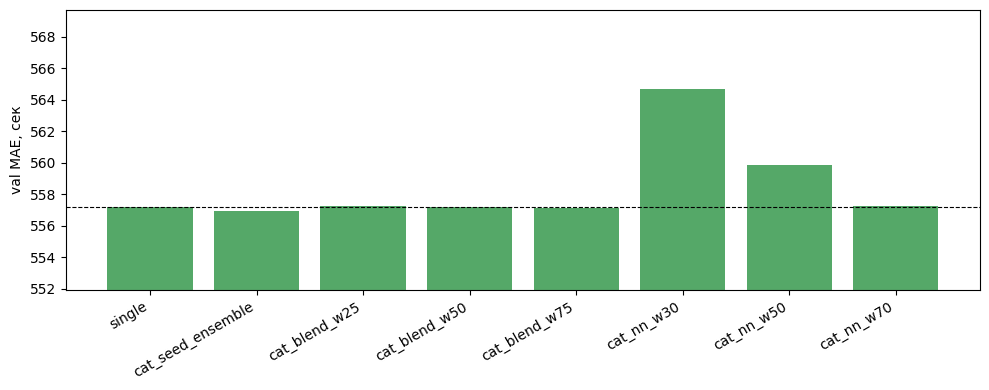

In [9]:
single = score(pack.yval, vlog)["mae"]
names = ["single"] + [r["model_name"] for r in rows]
vals = [single] + [r["val_mae"] for r in rows]
plt.figure(figsize=(10, 4))
plt.bar(names, vals, color="#55a868")
plt.axhline(single, color="k", ls="--", lw=0.8)
plt.ylabel("val MAE, сек")
plt.ylim(min(vals) - 5, max(vals) + 5)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Почему ансамбль не помогает
Сравниваю прогнозы и ошибки бустинга и сети на валидации.

корреляция прогнозов cat и nn: 0.89
корреляция ошибок cat и nn: 0.992


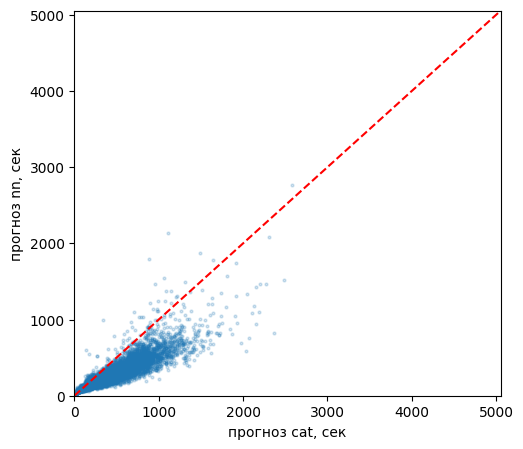

In [10]:
nnval = np.asarray(nn["val"], float)
print("корреляция прогнозов cat и nn:", round(np.corrcoef(vlog, nnval)[0, 1], 3))
ecat = np.abs(pack.yval - np.clip(vlog, 0, None))
enn = np.abs(pack.yval - np.clip(nnval, 0, None))
print("корреляция ошибок cat и nn:", round(np.corrcoef(ecat, enn)[0, 1], 3))
plt.figure(figsize=(5.5, 5))
plt.scatter(vlog, nnval, s=4, alpha=0.2)
lim = np.percentile(pack.yval, 99)
plt.plot([0, lim], [0, lim], "r--")
plt.xlim(0, lim)
plt.ylim(0, lim)
plt.xlabel("прогноз cat, сек")
plt.ylabel("прогноз nn, сек")
plt.show()

## Перебор веса блендинга

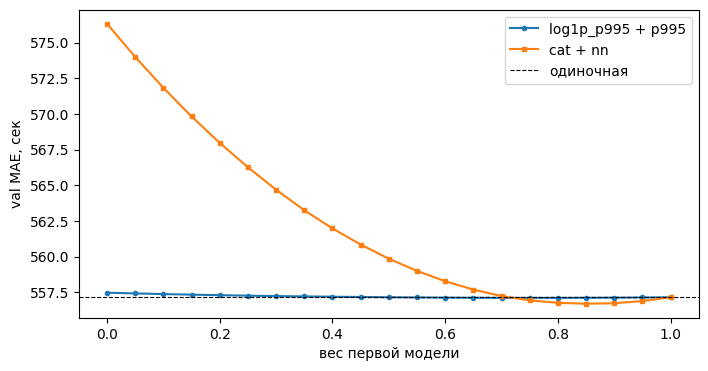

In [11]:
ws = np.arange(0, 1.01, 0.05)
scalemae = [score(pack.yval, w * vlog + (1 - w) * vp)["mae"] for w in ws]
catnnmae = [score(pack.yval, w * vlog + (1 - w) * nnval)["mae"] for w in ws]
plt.figure(figsize=(8, 4))
plt.plot(ws, scalemae, "o-", ms=3, label="log1p_p995 + p995")
plt.plot(ws, catnnmae, "s-", ms=3, label="cat + nn")
plt.axhline(score(pack.yval, vlog)["mae"], color="k", ls="--", lw=0.8, label="одиночная")
plt.xlabel("вес первой модели")
plt.ylabel("val MAE, сек")
plt.legend()
plt.show()

## Разброс seed ensemble

In [12]:
sv = np.vstack(seedval)
print("std прогноза между seed, медиана по объектам:", round(float(np.median(sv.std(0))), 1), "сек")
print("std самого таргета:", round(float(np.std(pack.yval)), 1), "сек")
for sd, p in zip([42, 52, 62], seedval):
    print("seed", sd, " val_mae", round(score(pack.yval, p)["mae"], 1))

std прогноза между seed, медиана по объектам: 10.3 сек
std самого таргета: 1620.9 сек
seed 42  val_mae 557.2
seed 52  val_mae 557.3
seed 62  val_mae 557.2


## Таблица результатов

In [13]:
res = pd.DataFrame(rows)
display(res[["model_name", "params", "val_mae", "val_r2", "test_mae"]].round(2))

,model_name,params,val_mae,val_r2,test_mae
0,cat_seed_ensemble,"seeds=42,52,62",556.93,0.02,600.69
1,cat_blend_w25,w_log=0.25,557.27,0.03,600.71
2,cat_blend_w50,w_log=0.5,557.16,0.03,600.66
3,cat_blend_w75,w_log=0.75,557.11,0.03,600.70
4,cat_nn_w30,w_cat=0.3,564.69,-0.01,609.89
5,cat_nn_w50,w_cat=0.5,559.86,0.00,604.99
6,cat_nn_w70,w_cat=0.7,557.24,0.01,601.90


In [14]:
pd.DataFrame(rows).to_csv("ensres.csv", index=False)
out = {}
for key, val in preds.items():
    out[labels[key[0]] + "|" + key[1]] = np.vstack(val)
np.savez("enspreds.npz", **out)